# День 5 — Error analysis

**Цель:** понять, где именно ошибается лучшая модель.

Скриптовый аналог: [`error_analysis.py`](../error_analysis.py).

In [1]:
import sys, os
# Добавляем корень проекта в путь, чтобы импортировать модули (config, preprocess, ...)
sys.path.insert(0, os.path.abspath('..'))

In [2]:
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from config import REPORTS_DIR, MODELS_DIR, ID2LABEL
from preprocess import load_and_preprocess
from train_improved import WordCharVectorizer  # нужно для загрузки векторайзера
%matplotlib inline

In [3]:
df = load_and_preprocess()
test_idx = json.loads((REPORTS_DIR / 'split_indices.json').read_text())['test']
model = joblib.load(MODELS_DIR / 'best_model.pkl')
vec = joblib.load(MODELS_DIR / 'best_vectorizer.pkl')

test_df = df.loc[test_idx].copy()
test_df['pred'] = model.predict(vec.transform(test_df['text_clean']))
labels = sorted(ID2LABEL); names = [ID2LABEL[i] for i in labels]
print(classification_report(test_df['label'], test_df['pred'], target_names=names, digits=4))

              precision    recall  f1-score   support

    negative     0.5263    0.6780    0.5926       118
     neutral     0.8265    0.8351    0.8307       576
    positive     0.7644    0.6819    0.7208       371

    accuracy                         0.7643      1065
   macro avg     0.7057    0.7317    0.7147      1065
weighted avg     0.7716    0.7643    0.7661      1065



## Confusion matrix

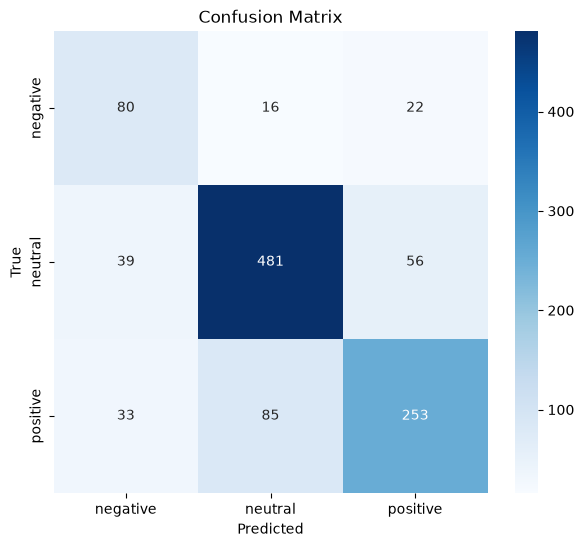

In [4]:
cm = confusion_matrix(test_df['label'], test_df['pred'], labels=labels)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=names, yticklabels=names)
plt.ylabel('True'); plt.xlabel('Predicted'); plt.title('Confusion Matrix'); plt.show()

## Частые типы ошибок и примеры

In [5]:
from collections import Counter
errors = test_df[test_df['label'] != test_df['pred']]
pairs = Counter((ID2LABEL[t], ID2LABEL[p]) for t, p in zip(errors['label'], errors['pred']))
for (t, p), c in pairs.most_common():
    print(f'{t} -> {p}: {c}')

positive -> neutral: 85
neutral -> positive: 56
neutral -> negative: 39
positive -> negative: 33
negative -> positive: 22
negative -> neutral: 16


In [6]:
L2I = {v: k for k, v in ID2LABEL.items()}
for (t, p), _ in pairs.most_common(3):
    sub = errors[(errors['label'] == L2I[t]) & (errors['pred'] == L2I[p])]
    print(f'\n[{t} -> {p}]')
    for txt in sub['text'].head(2):
        print('  -', txt[:160])


[positive -> neutral]
  - Last year the company raised its turnover to approximately 7 million litas EUR 2 mln , from 6.1 million litas in 2004 .
  - According to CEO Kai Telanne , the company 's newspapers achieved the best financial result ever .

[neutral -> positive]
  - RAPALA TOURNAMENT FISHING : With all the major titles already out for the holidays , bargain-priced games such as Rapala aim for a smaller audience .
  - Finnish Componenta has published its new long-term strategy for the period 2011-2015 with the aim of growing together with its customers .

[neutral -> negative]
  - ADPnews - Feb 5 , 2010 - Finnish real estate investor Sponda Oyj HEL : SDA1V said today that it slipped to a net loss of EUR 81.5 million USD 11.8 m in 2009 fro
  - The stock was hit by the profit warning of Finnish rival Rautaruukki Oyj ( OMX : RTRKS ) .


## Выводы
- Основная путаница — между `neutral` и `positive`.
- `negative` — самый редкий класс и самый низкий precision.
- Тяжелее всего длинные предложения с несколькими фактами разной тональности.
- Дальше: контекстные эмбеддинги (finBERT), больше данных класса `negative`.